# North San Andreas fault M7.6 Scenario

## 1. Setup

In [8]:
import os, json, shutil
from pathlib import Path
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import base64
from IPython.display import HTML

EVENT = 'bssc2014nsanandreassapsassha_m7p6_se'
os.environ['EVENT'] = EVENT

EVENT_DIR = Path.home() / 'shakemap_profiles/default/data' / EVENT / 'current'
PRODUCTS  = EVENT_DIR / 'products'
GF_OUT    = Path.home() / 'gf_output' / EVENT
CA_DATA   = Path('/workspaces/shakemap-gf-workshop/data/california_inputs')
PAGER_PNG = Path('/workspaces/shakemap-gf-workshop/data/pager/onepager.png')

In [6]:
%%bash
shake -v

ShakeMap version 4.4.9


## 2. Run ShakeMap

ShakeMap combines three types of input to estimate ground shaking:
- **Earthquake origin** — location, magnitude, depth, and fault geometry (`event.xml` + `rupture.json`)
- **Ground motion models (GMMs)** — equations that predict shaking from earthquakes
- **Site conditions (Vs30)** — local geology that amplifies or de-amplifies shaking (soft soils shake more than rock)

Four modules run in sequence:
- **`assemble`** — collect and validate all inputs
- **`model`** — compute ground motion at every grid point (computationally intense; about 1 minute to finish)
- **`contour`** — generate MMI shaking contour lines
- **`mapping`** — render map images (can take 30-45s)
- **`gridxml`** — export the grid file needed for ground failure models

Please be patient as it may take 1-2 minutes to run.

In [4]:
%%bash
shake $EVENT assemble -c 'demo' model contour mapping gridxml

INFO -- 2026-08-20 16:18:03 -- shake.main -- Running command assemble
INFO -- 2026-08-20 16:18:03 -- shake.main -- Finished running command assemble: Elapsed 0.17 secs
INFO -- 2026-08-20 16:18:03 -- shake.main -- Running command model
INFO -- 2026-08-20 16:18:03 -- model._threading_context -- BLAS thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-20 16:18:03 -- model._threading_context -- OpenMP thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-20 16:18:03 -- output_grid._adjust_resolution -- Resolution units specified in km, converting to degrees.
INFO -- 2026-08-20 16:18:03 -- output_grid._adjust_resolution -- Updated dx: 0.0169922 (degrees)
INFO -- 2026-08-20 16:18:03 -- output_grid._adjust_resolution -- Updated dy: 0.0134898 (degrees)
INFO -- 2026-08-20 16:18:34 -- shake.main -- Finished running command model: Elapsed 30.77 secs
INFO -- 2026-08-20 16:18:34 -- shake.main -- Running command contour
INFO -- 2026-08-20 16:18:35 -- shake.main 

## 3. ShakeMap maps

We will plot the **Modified Mercalli Intensity (MMI)** map — which
describes felt shaking in human terms — and the **Peak Ground Acceleration (PGA)**
map, which is used in engineering design.

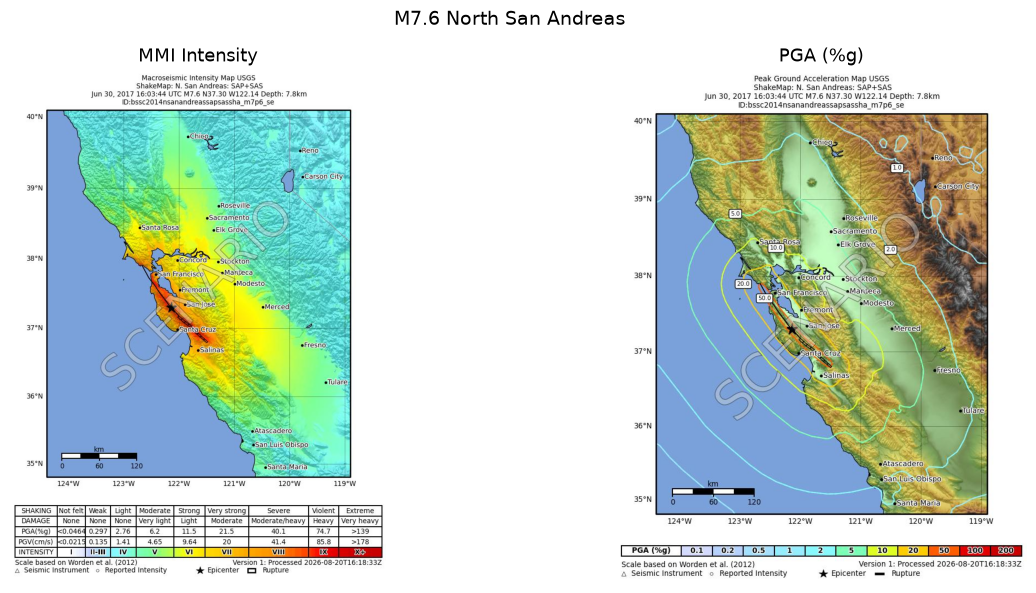

PosixPath('/home/vscode/san_andreas_ff_intensity.jpg')

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, name, title in [
    (axes[0], 'intensity.jpg', 'MMI Intensity'),
    (axes[1], 'pga.jpg',       'PGA (%g)'),
]:
    img_path = PRODUCTS / name
    if img_path.exists():
        ax.imshow(mpimg.imread(img_path))
    ax.set_title(title, fontsize=13); ax.axis('off')
plt.suptitle('M7.6 North San Andreas', fontsize=14)
plt.tight_layout(); plt.show()

shutil.copy(PRODUCTS / 'intensity.jpg',
            Path.home() / 'san_andreas_ff_intensity.jpg')

## 4. PAGER — Loss Estimates

PAGER estimates fatalities and economic losses using ShakeMap grids combined with
with population data (LandScan) and country-level building vulnerability models.

Note the separate alerts: California has earthquake-resistant construction
(yellow fatalities) but extremely high property values (red economic losses).

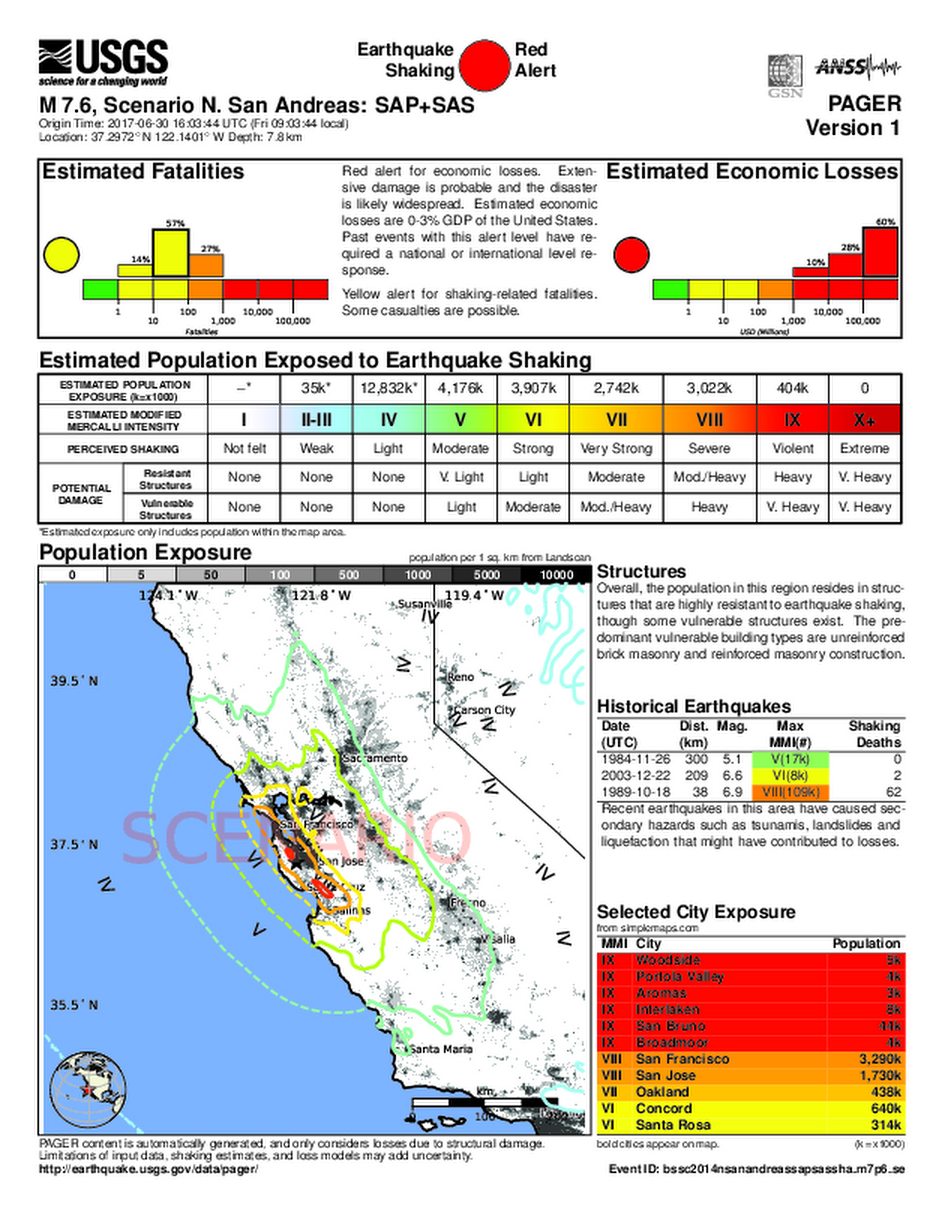

In [23]:
img = mpimg.imread(str(PAGER_PNG))
h, w = img.shape[:2]
fig, ax = plt.subplots(figsize=(w/100, h/100), dpi=150)
ax.imshow(img, interpolation='lanczos')
ax.axis('off')
plt.tight_layout(pad=0)
plt.show()

## 5. Ground failure

Ground failure models estimate secondary hazards triggered by the shaking:
- **Landslide probability** — Nowicki Jessee et al. (2018): uses slope, PGV, and susceptibility
- **Liquefaction probability** — Zhu et al. (2017): uses Vs30, distance to water, and precipitation

The Santa Cruz Mountains produce high landslide hazard; Bay mud deposits
along the bay margins produce high liquefaction hazard.

Note These models run in the `gf` conda environment — we call them by their full
path so we don't need to switch environments mid-notebook.

In [11]:
%%bash
/opt/conda/envs/gf/bin/gfailbin \
  ~/groundfailure/defaultconfigfiles/models/jessee_2018_slim.ini \
  ~/shakemap_profiles/default/data/$EVENT/current/products/grid.xml \
  --gis -d /workspaces/shakemap-gf-workshop/data/california_inputs


Running the following models:
	jessee_2018_slim
Applying bounds of lonmin -124.40, lonmax -118.89, latmin 34.79, latmax 40.10
Unable to determine source type, unknown if finite fault or point source

Now running jessee_2018_slim:

Files created:

/home/vscode/gf_output/bssc2014nsanandreassapsassha_m7p6_se/shakefile.txt
/home/vscode/gf_output/bssc2014nsanandreassapsassha_m7p6_se/bssc2014nsanandreassapsassha_m7p6_se_jessee_2018_slim_model.tif


In [13]:
%%bash
/opt/conda/envs/gf/bin/gfailbin \
  ~/groundfailure/defaultconfigfiles/models/zhu_2017_general_slim.ini \
  ~/shakemap_profiles/default/data/$EVENT/current/products/grid.xml \
  --gis -d /workspaces/shakemap-gf-workshop/data/california_inputs \


Running the following models:
	zhu_2017_general_slim
Applying bounds of lonmin -124.40, lonmax -118.89, latmin 34.79, latmax 40.10
Unable to determine source type, unknown if finite fault or point source

Now running zhu_2017_general_slim:

Files created:

/home/vscode/gf_output/bssc2014nsanandreassapsassha_m7p6_se/shakefile.txt
/home/vscode/gf_output/bssc2014nsanandreassapsassha_m7p6_se/bssc2014nsanandreassapsassha_m7p6_se_zhu_2017_general_slim_model.tif


## 6. Interactive ground failure map

The map below shows landslide (left) and liquefaction (right) probability
side by side, with shaking contours overlaid.

In [21]:
%%bash
/opt/conda/envs/gf/bin/python ~/plot_gf_interactive.py \
  --model "Jessee2018:$HOME/gf_output/$EVENT/${EVENT}_jessee_2018_slim_model.tif:$HOME/groundfailure/defaultconfigfiles/models/jessee_2018_slim.ini" \
  --model "Zhu2017:$HOME/gf_output/$EVENT/${EVENT}_zhu_2017_general_slim_model.tif:$HOME/groundfailure/defaultconfigfiles/models/zhu_2017_general_slim.ini" \
  --shakefile ~/shakemap_profiles/default/data/$EVENT/current/products/grid.xml \
  --contours  ~/shakemap_profiles/default/data/$EVENT/current/products/cont_mmi.json \
  --outfile ~/san_andreas_gf.html

Reading /home/vscode/gf_output/bssc2014nsanandreassapsassha_m7p6_se/bssc2014nsanandreassapsassha_m7p6_se_jessee_2018_slim_model.tif...
Reading /home/vscode/gf_output/bssc2014nsanandreassapsassha_m7p6_se/bssc2014nsanandreassapsassha_m7p6_se_zhu_2017_general_slim_model.tif...
Saved: /home/vscode/san_andreas_gf.html
[Jessee2018] max P: 0.2372, area>0.002: 6.1%
[Zhu2017] max P: 0.4280, area>0.002: 35.5%


In [22]:
html_path = Path.home() / 'san_andreas_gf.html'
b64 = base64.b64encode(html_path.read_bytes()).decode()
HTML(f'<iframe src="data:text/html;base64,{b64}" width="100%" height="600px"></iframe>')

/opt/conda/envs/shakemap/lib/python3.12/site-packages/IPython/core/display.py:452: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


---